# 11 - Mean-Field Variational Bayes for Bayesian Linear Regression



MFVB (Mean-Field Variational Bayes) is a **variational inference technique**, not a standalone Python library.



Libraries such as PyMC, Pyro, and TensorFlow Probability can be used to build mean-field approximations, but in this notebook the core idea is implemented directly to keep it simple.



We will:

1. generate synthetic data

2. fit a mean-field variational approximation

3. check ELBO convergence

4. compare true and estimated parameters


In [11]:
import numpy as np

import matplotlib.pyplot as plt

from dataclasses import dataclass, field

from scipy.special import digamma, gammaln



plt.style.use('seaborn-v0_8-whitegrid')

np.set_printoptions(precision=4, suppress=True)





@dataclass(slots=True)

class BLRDataset:

    X: np.ndarray

    y: np.ndarray

    true_beta: np.ndarray | None = None

    true_tau: float | None = None





@dataclass(slots=True)

class PriorConfig:

    m0: np.ndarray

    S0: np.ndarray

    a0: float = 1.0

    b0: float = 1.0



    @classmethod

    def isotropic(

        cls,

        n_features: int,

        mean: float = 0.0,

        precision: float = 1.0,

        a0: float = 1.0,

        b0: float = 1.0,

    ) -> "PriorConfig":

        return cls(

            m0=np.full(n_features, mean, dtype=float),

            S0=precision * np.eye(n_features, dtype=float),

            a0=a0,

            b0=b0,

        )





@dataclass(slots=True)

class MFVBConfig:

    max_iter: int = 1000

    tol: float = 1e-8

    verbose: bool = False





@dataclass(slots=True)

class MFVBResult:

    m_n: np.ndarray

    S_n: np.ndarray

    a_n: float

    b_n: float

    elbo_history: list[float] = field(default_factory=list)

    converged: bool = False

    n_iter: int = 0



    @property

    def expected_beta(self) -> np.ndarray:

        return self.m_n



    @property

    def expected_tau(self) -> float:

        return self.a_n / self.b_n





def generate_synthetic_blr(

    n_samples: int,

    n_features: int,

    true_beta: np.ndarray | None = None,

    true_tau: float = 4.0,

    x_scale: float = 1.0,

    random_state: int | None = None,

) -> BLRDataset:

    rng = np.random.default_rng(random_state)

    X = rng.normal(loc=0.0, scale=x_scale, size=(n_samples, n_features))



    if true_beta is None:

        true_beta = rng.normal(loc=0.0, scale=1.0, size=n_features)

    else:

        true_beta = np.asarray(true_beta, dtype=float)



    noise = rng.normal(loc=0.0, scale=np.sqrt(1.0 / true_tau), size=n_samples)

    y = X @ true_beta + noise

    return BLRDataset(X=X, y=y, true_beta=true_beta, true_tau=float(true_tau))





def _expected_residual_sum_squares(

    X: np.ndarray,

    y: np.ndarray,

    m_n: np.ndarray,

    S_n: np.ndarray,

) -> float:

    residual = y - X @ m_n

    return float(residual @ residual + np.trace(X @ S_n @ X.T))





def compute_elbo(dataset: BLRDataset, prior: PriorConfig, result: MFVBResult) -> float:

    X, y = dataset.X, dataset.y

    n, p = X.shape



    m0, S0, a0, b0 = prior.m0, prior.S0, prior.a0, prior.b0

    m_n, S_n, a_n, b_n = result.m_n, result.S_n, result.a_n, result.b_n



    e_tau = a_n / b_n

    e_log_tau = digamma(a_n) - np.log(b_n)

    rss_exp = _expected_residual_sum_squares(X, y, m_n, S_n)



    sign_s0, logdet_s0 = np.linalg.slogdet(S0)

    sign_sn, logdet_sn = np.linalg.slogdet(S_n)

    if sign_s0 <= 0 or sign_sn <= 0:

        raise ValueError('Precision matrices must be positive definite.')



    centered = m_n - m0

    eq_log_p_y = 0.5 * n * (e_log_tau - np.log(2.0 * np.pi)) - 0.5 * e_tau * rss_exp

    eq_log_p_beta = 0.5 * logdet_s0 - 0.5 * p * np.log(2.0 * np.pi)

    eq_log_p_beta -= 0.5 * (centered @ S0 @ centered + np.trace(S0 @ S_n))

    eq_log_p_tau = a0 * np.log(b0) - gammaln(a0) + (a0 - 1.0) * e_log_tau - b0 * e_tau



    eq_log_q_beta = -0.5 * (p * (1.0 + np.log(2.0 * np.pi)) + logdet_sn)

    eq_log_q_tau = a_n * np.log(b_n) - gammaln(a_n) + (a_n - 1.0) * e_log_tau - a_n



    return float(eq_log_p_y + eq_log_p_beta + eq_log_p_tau - eq_log_q_beta - eq_log_q_tau)





def fit_mfvb_blr(

    dataset: BLRDataset,

    prior: PriorConfig,

    config: MFVBConfig | None = None,

) -> MFVBResult:

    if config is None:

        config = MFVBConfig()



    X, y = dataset.X, dataset.y

    n, _ = X.shape

    XtX = X.T @ X

    Xty = X.T @ y



    m0, S0, a0, b0 = prior.m0, prior.S0, prior.a0, prior.b0



    m_n = m0.copy()

    S_n = np.linalg.inv(S0 + XtX)

    a_n = a0 + n / 2.0

    b_n = b0 + 1.0



    elbo_history: list[float] = []

    converged = False



    for iteration in range(1, config.max_iter + 1):

        e_tau = a_n / b_n

        S_n_inv = S0 + e_tau * XtX

        S_n = np.linalg.inv(S_n_inv)

        m_n = S_n @ (S0 @ m0 + e_tau * Xty)



        rss_exp = _expected_residual_sum_squares(X, y, m_n, S_n)

        a_n = a0 + n / 2.0

        b_n = b0 + 0.5 * rss_exp



        result = MFVBResult(m_n=m_n, S_n=S_n, a_n=a_n, b_n=b_n)

        elbo = compute_elbo(dataset, prior, result)

        elbo_history.append(elbo)



        if config.verbose:

            print(f'iter={iteration:04d} elbo={elbo:.6f} E[tau]={result.expected_tau:.6f}')



        if len(elbo_history) > 1 and abs(elbo_history[-1] - elbo_history[-2]) < config.tol:

            converged = True

            break



    return MFVBResult(

        m_n=m_n,

        S_n=S_n,

        a_n=a_n,

        b_n=b_n,

        elbo_history=elbo_history,

        converged=converged,

        n_iter=len(elbo_history),

    )


## Part 1: Synthetic data



We start with synthetic data so we know the true coefficients and noise precision.


In [12]:
true_beta = np.array([1.5, -0.8, 0.3, 2.0])
true_tau = 4.0  # precision = 1 / variance

dataset = generate_synthetic_blr(
    n_samples=200,
    n_features=len(true_beta),
    true_beta=true_beta,
    true_tau=true_tau,
    random_state=42,
)

print('X shape:', dataset.X.shape)
print('y shape:', dataset.y.shape)
print('True beta:', dataset.true_beta)
print('True tau:', dataset.true_tau)

X shape: (200, 4)
y shape: (200,)
True beta: [ 1.5 -0.8  0.3  2. ]
True tau: 4.0


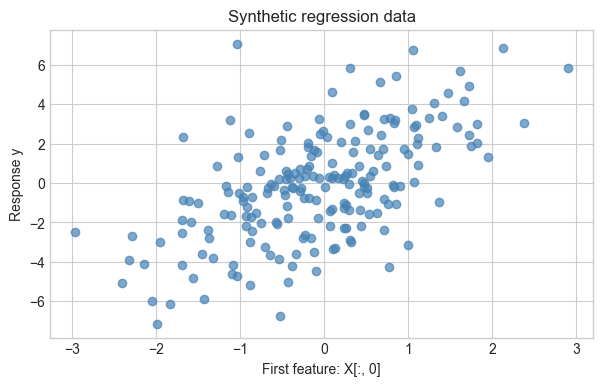

In [3]:
# Look at the first feature against the response
plt.figure(figsize=(7, 4))
plt.scatter(dataset.X[:, 0], dataset.y, alpha=0.7, color='steelblue')
plt.xlabel('First feature: X[:, 0]')
plt.ylabel('Response y')
plt.title('Synthetic regression data')
plt.show()

## Part 2: Fit the mean-field approximation



Here MFVB means a factorized variational approximation for the posterior over `beta` and `tau`.


In [13]:
prior = PriorConfig.isotropic(
    n_features=dataset.X.shape[1],
    mean=0.0,
    precision=1.0,
    a0=1.0,
    b0=1.0,
)

config = MFVBConfig(max_iter=2000, tol=1e-10, verbose=False)
result = fit_mfvb_blr(dataset, prior, config)

print('Converged:', result.converged)
print('Iterations:', result.n_iter)
print('Estimated beta:', result.expected_beta)
print('Estimated tau:', result.expected_tau)
print('Final ELBO:', result.elbo_history[-1])

Converged: True
Iterations: 5
Estimated beta: [ 1.521  -0.8156  0.3219  1.973 ]
Estimated tau: 3.761214780228646
Final ELBO: -166.9926226598281


## Part 3: ELBO convergence



The ELBO should increase and then level off.


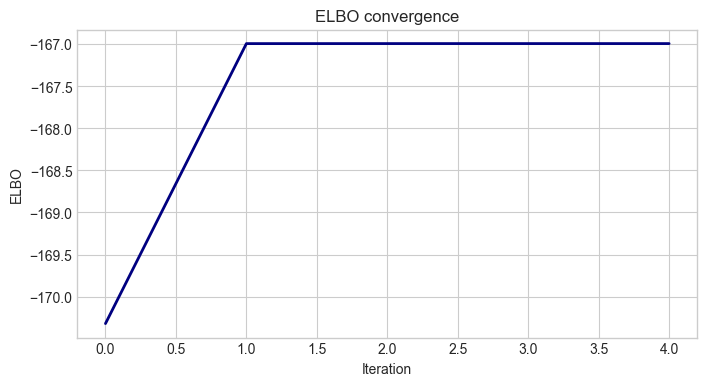

Minimum ELBO change: 5.118749868415762e-11
Last ELBO change: 5.118749868415762e-11


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(result.elbo_history, color='navy', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.title('ELBO convergence')
plt.show()

elbo_diffs = np.diff(result.elbo_history)
print('Minimum ELBO change:', elbo_diffs.min() if len(elbo_diffs) else 'N/A')
print('Last ELBO change:', elbo_diffs[-1] if len(elbo_diffs) else 'N/A')

## Part 4: Compare estimates



Now compare the true values with the MFVB estimates.


In [6]:
beta_error = result.expected_beta - dataset.true_beta
beta_mse = np.mean(beta_error**2)
tau_error = result.expected_tau - dataset.true_tau

print('True beta:     ', dataset.true_beta)
print('Estimated beta:', np.round(result.expected_beta, 4))
print('Beta error:    ', np.round(beta_error, 4))
print('Beta MSE:      ', round(float(beta_mse), 6))
print()
print('True tau:      ', round(float(dataset.true_tau), 4))
print('Estimated tau: ', round(float(result.expected_tau), 4))
print('Tau error:     ', round(float(tau_error), 4))

True beta:      [ 1.5 -0.8  0.3  2. ]
Estimated beta: [ 1.521  -0.8156  0.3219  1.973 ]
Beta error:     [ 0.021  -0.0156  0.0219 -0.027 ]
Beta MSE:       0.000474

True tau:       4.0
Estimated tau:  3.7612
Tau error:      -0.2388


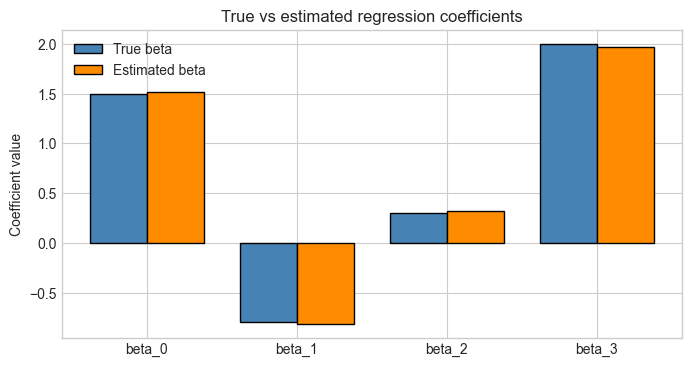

In [7]:
indices = np.arange(len(true_beta))
width = 0.38

plt.figure(figsize=(8, 4))
plt.bar(indices - width / 2, dataset.true_beta, width=width, label='True beta', color='steelblue', edgecolor='black')
plt.bar(indices + width / 2, result.expected_beta, width=width, label='Estimated beta', color='darkorange', edgecolor='black')
plt.xticks(indices, [f'beta_{i}' for i in range(len(true_beta))])
plt.ylabel('Coefficient value')
plt.title('True vs estimated regression coefficients')
plt.legend()
plt.show()

## Summary



This notebook shows a simple Mean-Field Variational Bayes baseline for Bayesian linear regression.



1. generate synthetic data with known truth

2. fit a factorized variational approximation

3. check ELBO convergence

4. compare true and estimated parameters


In [8]:
# Optional exercises
# 1) Change true_beta and true_tau, then rerun the notebook.
# 2) Try a stronger prior by increasing the prior precision.
# 3) Increase the number of features and see how recovery changes.

pass